# Phase 5 — Exploratory Data Analysis and Visualization

This notebook will visually and statistically explore encounter-level patterns associated with 30-day hospital readmission using the cleaned dataset produced in Phase 3. The analysis treats each row as an encounter, and `readmitted = '<30'` represents a 30-day readmission.

All findings will be interpreted as descriptive associations and will not establish causation. Important EDA results will later be cross-validated against the Phase 4 SQL findings.

In [13]:
import sys
print(sys.executable)

/Users/josmithareddy/Documents/Data-Analyst-Projects/hospital-readmission-risk-analysis/.venv/bin/python


## Setup and data loading

In [17]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Project paths

Resolve the project root from the current working directory or one of its parents so the notebook works from both the project root and the `notebooks` directory.

In [19]:
current_path = Path.cwd().resolve()
candidate_roots = (current_path, *current_path.parents)

project_root = next(
    (
        candidate
        for candidate in candidate_roots
        if (candidate / "data" / "processed" / "diabetic_data_cleaned.csv").is_file()
    ),
    None,
)

if project_root is None:
    raise FileNotFoundError(
        "Could not locate data/processed/diabetic_data_cleaned.csv from the "
        "current directory or any parent directory. Generate the cleaned "
        "Phase 3 dataset before running this notebook."
    )

processed_data_path = project_root / "data" / "processed" / "diabetic_data_cleaned.csv"

if not processed_data_path.is_file():
    raise FileNotFoundError(f"Cleaned dataset not found: {processed_data_path}")

### Load the cleaned dataset

Load the Phase 3 output without transforming or overwriting the source file.

In [20]:
df = pd.read_csv(processed_data_path)

print(f"Dataset path: {processed_data_path.resolve()}")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")

Dataset path: /Users/josmithareddy/Documents/Data-Analyst-Projects/hospital-readmission-risk-analysis/data/processed/diabetic_data_cleaned.csv
Rows: 101,763
Columns: 48


## Dataset validation

Confirm that the loaded data matches the validated Phase 3 and Phase 4 dataset dimensions, identifiers, and readmission outcome totals before beginning EDA.

In [21]:
expected_readmission_values = {"NO", ">30", "<30"}
unique_encounters = df["encounter_id"].nunique()
unique_patients = df["patient_nbr"].nunique()
readmitted_within_30_days = df["readmitted"].eq("<30").sum()
readmission_rate_pct = df["readmitted"].eq("<30").mean() * 100
observed_readmission_values = set(df["readmitted"].dropna().unique())

assert df.shape == (101_763, 48), f"Unexpected shape: {df.shape}"
assert df["encounter_id"].is_unique, "encounter_id must be unique."
assert unique_encounters == 101_763, f"Unexpected unique encounter count: {unique_encounters:,}"
assert unique_patients == 71_515, f"Unexpected unique patient count: {unique_patients:,}"
assert readmitted_within_30_days == 11_357, (
    f"Unexpected 30-day readmission count: {readmitted_within_30_days:,}"
)
assert observed_readmission_values == expected_readmission_values, (
    f"Unexpected readmitted values: {sorted(observed_readmission_values)}"
)

validation_summary = pd.DataFrame(
    {
        "metric": [
            "Rows",
            "Columns",
            "Unique encounter IDs",
            "Unique patients",
            "30-day readmissions",
            "30-day readmission rate",
        ],
        "calculated_value": [
            f"{df.shape[0]:,}",
            f"{df.shape[1]:,}",
            f"{unique_encounters:,}",
            f"{unique_patients:,}",
            f"{readmitted_within_30_days:,}",
            f"{readmission_rate_pct:.2f}%",
        ],
    }
)

print("Dataset validation passed.")
validation_summary

Dataset validation passed.


,metric,calculated_value
0,Rows,"101,763"
1,Columns,48
2,Unique encounter IDs,"101,763"
3,Unique patients,"71,515"
4,30-day readmissions,"11,357"
5,30-day readmission rate,11.16%


## Analytical target

Create an in-memory binary target for concise calculations throughout the notebook. This field is added only to the notebook DataFrame; the processed CSV is not modified.

In [22]:
df["readmit_30_flag"] = df["readmitted"].eq("<30").astype(int)

assert df["readmit_30_flag"].sum() == 11_357, (
    "readmit_30_flag does not match the validated 30-day readmission count."
)

readmit_30_rate_pct = df["readmit_30_flag"].mean() * 100
print(f"30-day readmission rate: {readmit_30_rate_pct:.2f}%")

30-day readmission rate: 11.16%


## Initial EDA Data Overview

Review a small sample, schema information, numeric summaries, and compact column-level metadata before conducting focused exploratory analysis.

In [23]:
df.head()

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,medical_specialty,...,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,readmit_30_flag
0,2278392,8222157,Caucasian,Female,[0-10),6,25,1,1,Pediatrics-Endocrinology,...,No,No,No,No,No,No,No,No,NO,0
1,149190,55629189,Caucasian,Female,[10-20),1,1,7,3,Unknown,...,Up,No,No,No,No,No,Ch,Yes,>30,0
2,64410,86047875,AfricanAmerican,Female,[20-30),1,1,7,2,Unknown,...,No,No,No,No,No,No,No,Yes,NO,0
3,500364,82442376,Caucasian,Male,[30-40),1,1,7,2,Unknown,...,Up,No,No,No,No,No,Ch,Yes,NO,0
4,16680,42519267,Caucasian,Male,[40-50),1,1,7,1,Unknown,...,Steady,No,No,No,No,No,Ch,Yes,NO,0


In [24]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 101763 entries, 0 to 101762
Data columns (total 49 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   encounter_id              101763 non-null  int64
 1   patient_nbr               101763 non-null  int64
 2   race                      99492 non-null   str  
 3   gender                    101763 non-null  str  
 4   age                       101763 non-null  str  
 5   admission_type_id         101763 non-null  int64
 6   discharge_disposition_id  101763 non-null  int64
 7   admission_source_id       101763 non-null  int64
 8   time_in_hospital          101763 non-null  int64
 9   medical_specialty         101763 non-null  str  
 10  num_lab_procedures        101763 non-null  int64
 11  num_procedures            101763 non-null  int64
 12  num_medications           101763 non-null  int64
 13  number_outpatient         101763 non-null  int64
 14  number_emergency          10176

In [25]:
numeric_summary = df.select_dtypes(include=np.number).describe().T
numeric_summary

,count,mean,std,min,25%,50%,75%,max
encounter_id,101763.0,1.652008e+08,1.026410e+08,12522.0,84959748.0,152388294.0,230269803.0,443867222.0
patient_nbr,101763.0,5.432965e+07,3.869658e+07,135.0,23412964.5,45500490.0,87545713.5,189502619.0
admission_type_id,101763.0,2.024017e+00,1.445414e+00,1.0,1.0,1.0,3.0,8.0
discharge_disposition_id,101763.0,3.715515e+00,5.279919e+00,1.0,1.0,1.0,4.0,28.0
admission_source_id,101763.0,5.754459e+00,4.064110e+00,1.0,1.0,7.0,7.0,25.0
time_in_hospital,101763.0,4.396018e+00,2.985092e+00,1.0,2.0,4.0,6.0,14.0
num_lab_procedures,101763.0,4.309591e+01,1.967422e+01,1.0,31.0,44.0,57.0,132.0
num_procedures,101763.0,1.339691e+00,1.705792e+00,0.0,0.0,1.0,2.0,6.0
num_medications,101763.0,1.602184e+01,8.127589e+00,1.0,10.0,15.0,20.0,81.0
number_outpatient,101763.0,3.693680e-01,1.267282e+00,0.0,0.0,0.0,0.0,42.0


In [11]:
numeric_column_count = df.select_dtypes(include=np.number).shape[1]
non_numeric_column_count = df.shape[1] - numeric_column_count

print(f"Numeric columns: {numeric_column_count}")
print(f"Non-numeric columns: {non_numeric_column_count}")

Numeric columns: 14
Non-numeric columns: 35


In [26]:
column_overview = pd.DataFrame(
    {
        "column": df.columns,
        "dtype": df.dtypes.astype(str).values,
        "non_null_count": df.notna().sum().values,
        "missing_count": df.isna().sum().values,
        "unique_count": df.nunique(dropna=True).values,
    }
)

column_overview

,column,dtype,non_null_count,missing_count,unique_count
0,encounter_id,int64,101763,0,101763
1,patient_nbr,int64,101763,0,71515
2,race,str,99492,2271,5
3,gender,str,101763,0,2
4,age,str,101763,0,10
5,admission_type_id,int64,101763,0,8
6,discharge_disposition_id,int64,101763,0,26
7,admission_source_id,int64,101763,0,17
8,time_in_hospital,int64,101763,0,14
9,medical_specialty,str,101763,0,73


In [27]:
readmission_order = ["NO", ">30", "<30"]
readmission_counts = df["readmitted"].value_counts().reindex(readmission_order)

readmission_distribution = pd.DataFrame(
    {
        "readmitted": readmission_order,
        "encounter_count": readmission_counts.to_numpy(),
        "percentage_of_total": (readmission_counts.to_numpy() / len(df) * 100).round(2),
    }
)

readmission_distribution

,readmitted,encounter_count,percentage_of_total
0,NO,54861,53.91
1,>30,35545,34.93
2,<30,11357,11.16


## 30-day readmission binary summary

In [28]:
total_encounters = len(df)
readmit_30_count = int(df["readmit_30_flag"].sum())
no_readmit_30_count = total_encounters - readmit_30_count
readmit_30_rate_pct = df["readmit_30_flag"].mean() * 100

readmit_30_summary = pd.DataFrame(
    {
        "metric": [
            "Total encounters",
            "30-day readmissions",
            "Encounters without 30-day readmission",
            "30-day readmission rate (%)",
        ],
        "value": [
            total_encounters,
            readmit_30_count,
            no_readmit_30_count,
            round(readmit_30_rate_pct, 2),
        ],
    }
)

readmit_30_summary

,metric,value
0,Total encounters,101763.00
1,30-day readmissions,11357.00
2,Encounters without 30-day readmission,90406.00
3,30-day readmission rate (%),11.16


## Readmission category visualization

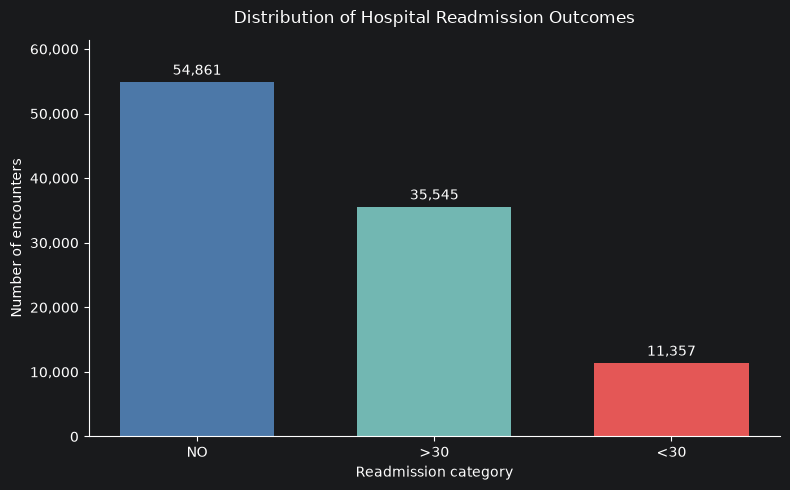

In [29]:
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(
    readmission_distribution["readmitted"],
    readmission_distribution["encounter_count"],
    color=["#4C78A8", "#72B7B2", "#E45756"],
    width=0.65,
)

ax.set_title("Distribution of Hospital Readmission Outcomes", pad=12)
ax.set_xlabel("Readmission category")
ax.set_ylabel("Number of encounters")
ax.yaxis.set_major_formatter("{x:,.0f}")
ax.bar_label(
    bars,
    labels=[f"{value:,.0f}" for value in readmission_distribution["encounter_count"]],
    padding=3,
)
ax.spines[["top", "right"]].set_visible(False)
ax.set_ylim(0, readmission_distribution["encounter_count"].max() * 1.12)
plt.tight_layout()
plt.show()

## 30-day readmission rate visualization

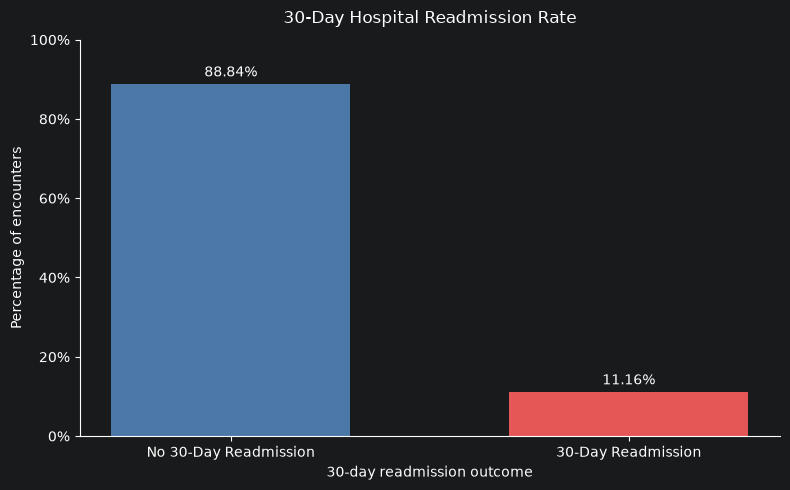

In [30]:
binary_labels = ["No 30-Day Readmission", "30-Day Readmission"]
binary_percentages = (
    df["readmit_30_flag"].value_counts(normalize=True).reindex([0, 1]) * 100
)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(
    binary_labels,
    binary_percentages.to_numpy(),
    color=["#4C78A8", "#E45756"],
    width=0.6,
)

ax.set_title("30-Day Hospital Readmission Rate", pad=12)
ax.set_xlabel("30-day readmission outcome")
ax.set_ylabel("Percentage of encounters")
ax.yaxis.set_major_formatter("{x:.0f}%")
ax.bar_label(
    bars,
    labels=[f"{value:.2f}%" for value in binary_percentages],
    padding=3,
)
ax.spines[["top", "right"]].set_visible(False)
ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()

## Cross-check with Phase 4

In [31]:
assert total_encounters == 101_763, f"Unexpected encounter count: {total_encounters:,}"
assert readmit_30_count == 11_357, (
    f"Unexpected 30-day readmission count: {readmit_30_count:,}"
)
assert round(readmit_30_rate_pct, 2) == 11.16, (
    f"Unexpected 30-day readmission rate: {readmit_30_rate_pct:.2f}%"
)

print("EDA baseline matches the validated Phase 4 SQL results.")

EDA baseline matches the validated Phase 4 SQL results.


In [32]:
age_order = [
    "[0-10)",
    "[10-20)",
    "[20-30)",
    "[30-40)",
    "[40-50)",
    "[50-60)",
    "[60-70)",
    "[70-80)",
    "[80-90)",
    "[90-100)",
]

age_summary = (
    df.groupby("age")
    .agg(
        total_encounters=("encounter_id", "size"),
        readmitted_within_30_days=("readmit_30_flag", "sum"),
    )
    .reindex(age_order)
    .reset_index()
)
age_summary["readmission_rate_pct"] = (
    age_summary["readmitted_within_30_days"]
    / age_summary["total_encounters"]
    * 100
).round(2)

age_summary

,age,total_encounters,readmitted_within_30_days,readmission_rate_pct
0,[0-10),161,3,1.86
1,[10-20),691,40,5.79
2,[20-30),1657,236,14.24
3,[30-40),3775,424,11.23
4,[40-50),9685,1027,10.60
5,[50-60),17256,1668,9.67
6,[60-70),22482,2502,11.13
7,[70-80),26066,3069,11.77
8,[80-90),17197,2078,12.08
9,[90-100),2793,310,11.10


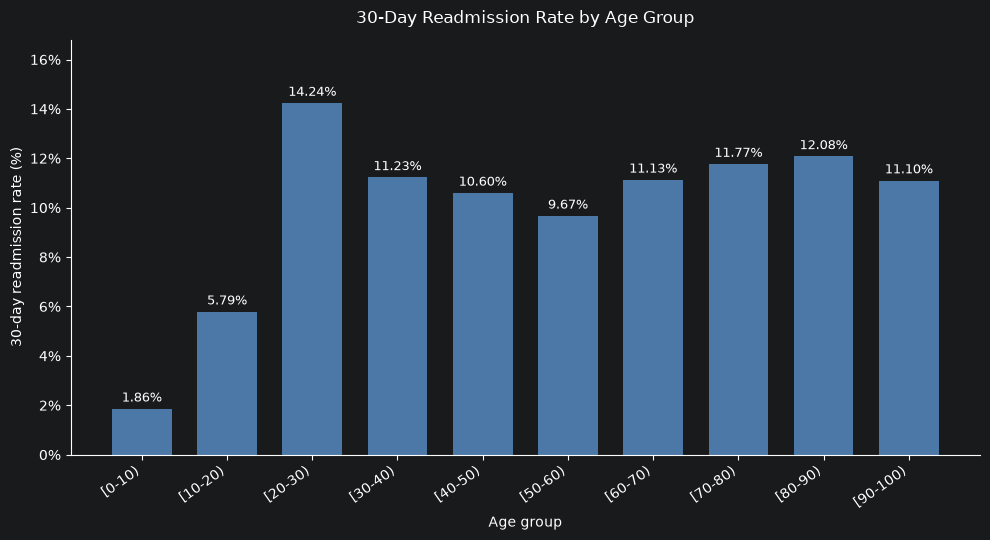

In [33]:
fig, ax = plt.subplots(figsize=(10, 5.5))
bars = ax.bar(
    age_summary["age"],
    age_summary["readmission_rate_pct"],
    color="#4C78A8",
    width=0.7,
)

ax.set_title("30-Day Readmission Rate by Age Group", pad=12)
ax.set_xlabel("Age group")
ax.set_ylabel("30-day readmission rate (%)")
ax.yaxis.set_major_formatter("{x:.0f}%")
ax.bar_label(
    bars,
    labels=[f"{rate:.2f}%" for rate in age_summary["readmission_rate_pct"]],
    padding=3,
    fontsize=9,
)
ax.spines[["top", "right"]].set_visible(False)
ax.set_ylim(0, age_summary["readmission_rate_pct"].max() * 1.18)
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

### Phase 4 age cross-validation

In [34]:
expected_age_totals = [161, 691, 1_657, 3_775, 9_685, 17_256, 22_482, 26_066, 17_197, 2_793]
expected_age_readmissions = [3, 40, 236, 424, 1_027, 1_668, 2_502, 3_069, 2_078, 310]
expected_age_rates = [1.86, 5.79, 14.24, 11.23, 10.60, 9.67, 11.13, 11.77, 12.08, 11.10]

assert age_summary["age"].tolist() == age_order, "Age groups are not in the expected order."
assert age_summary["total_encounters"].tolist() == expected_age_totals, (
    "Age-group encounter totals do not match the validated Phase 4 SQL results."
)
assert age_summary["readmitted_within_30_days"].tolist() == expected_age_readmissions, (
    "Age-group readmission totals do not match the validated Phase 4 SQL results."
)
assert age_summary["readmission_rate_pct"].round(2).tolist() == expected_age_rates, (
    "Age-group readmission rates do not match the validated Phase 4 SQL results."
)

print("Age results match the validated Phase 4 SQL results.")

Age results match the validated Phase 4 SQL results.


## Gender analysis

In [35]:
gender_summary = (
    df.groupby("gender", dropna=False)
    .agg(
        total_encounters=("encounter_id", "size"),
        readmitted_within_30_days=("readmit_30_flag", "sum"),
    )
    .reset_index()
)
gender_summary["readmission_rate_pct"] = (
    gender_summary["readmitted_within_30_days"]
    / gender_summary["total_encounters"]
    * 100
).round(2)
gender_summary = gender_summary.sort_values(
    ["readmission_rate_pct", "gender"], ascending=[False, True]
).reset_index(drop=True)

gender_summary

,gender,total_encounters,readmitted_within_30_days,readmission_rate_pct
0,Female,54708,6152,11.25
1,Male,47055,5205,11.06


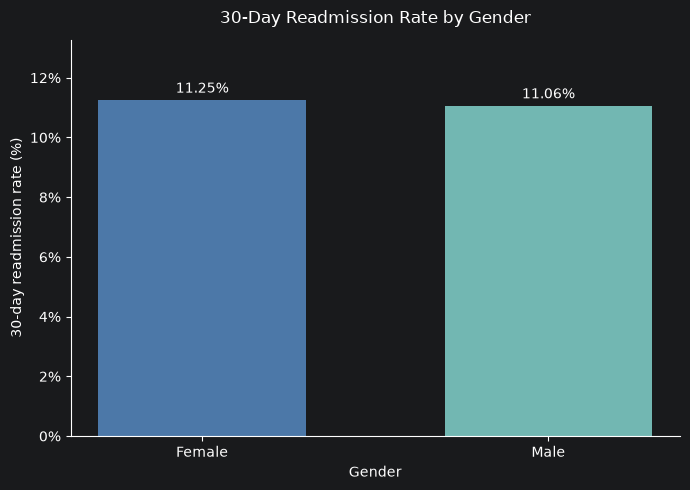

In [24]:
fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(
    gender_summary["gender"].astype(str),
    gender_summary["readmission_rate_pct"],
    color=["#4C78A8", "#72B7B2"],
    width=0.6,
)

ax.set_title("30-Day Readmission Rate by Gender", pad=12)
ax.set_xlabel("Gender")
ax.set_ylabel("30-day readmission rate (%)")
ax.yaxis.set_major_formatter("{x:.0f}%")
ax.bar_label(
    bars,
    labels=[f"{rate:.2f}%" for rate in gender_summary["readmission_rate_pct"]],
    padding=3,
)
ax.spines[["top", "right"]].set_visible(False)
ax.set_ylim(0, gender_summary["readmission_rate_pct"].max() * 1.18)
plt.tight_layout()
plt.show()

## Race analysis

Missing or blank race values are retained as `Missing/Unknown` rather than silently excluded.

In [36]:
race_for_analysis = (
    df["race"]
    .astype("string")
    .str.strip()
    .replace({"": pd.NA, "?": pd.NA})
    .fillna("Missing/Unknown")
)

race_summary = (
    df.assign(race_analysis=race_for_analysis)
    .groupby("race_analysis", dropna=False)
    .agg(
        total_encounters=("encounter_id", "size"),
        readmitted_within_30_days=("readmit_30_flag", "sum"),
    )
    .reset_index()
    .rename(columns={"race_analysis": "race"})
)
race_summary["readmission_rate_pct"] = (
    race_summary["readmitted_within_30_days"]
    / race_summary["total_encounters"]
    * 100
).round(2)
race_summary = race_summary.sort_values(
    ["readmission_rate_pct", "race"], ascending=[False, True]
).reset_index(drop=True)

race_summary

,race,total_encounters,readmitted_within_30_days,readmission_rate_pct
0,Caucasian,76099,8592,11.29
1,AfricanAmerican,19210,2155,11.22
2,Hispanic,2037,212,10.41
3,Asian,641,65,10.14
4,Other,1505,145,9.63
5,Missing/Unknown,2271,188,8.28


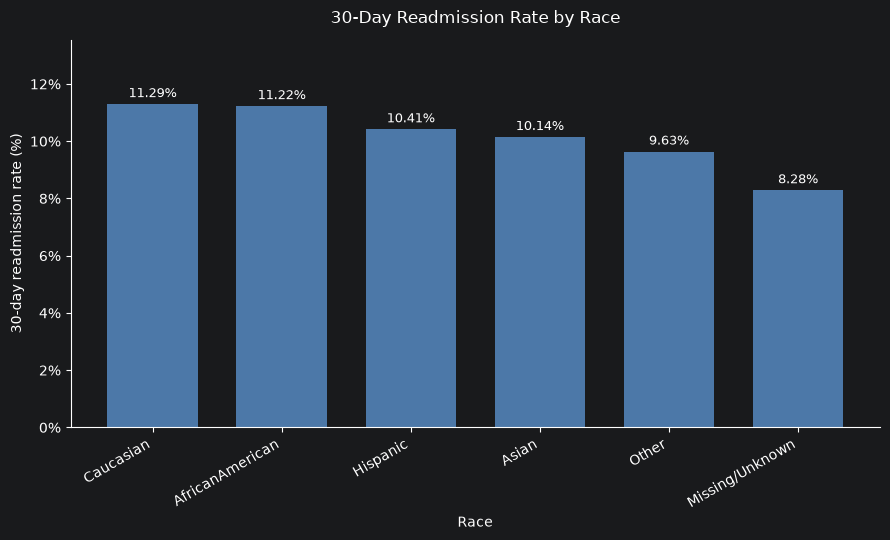

In [37]:
fig, ax = plt.subplots(figsize=(9, 5.5))
bars = ax.bar(
    race_summary["race"].astype(str),
    race_summary["readmission_rate_pct"],
    color="#4C78A8",
    width=0.7,
)

ax.set_title("30-Day Readmission Rate by Race", pad=12)
ax.set_xlabel("Race")
ax.set_ylabel("30-day readmission rate (%)")
ax.yaxis.set_major_formatter("{x:.0f}%")
ax.bar_label(
    bars,
    labels=[f"{rate:.2f}%" for rate in race_summary["readmission_rate_pct"]],
    padding=3,
    fontsize=9,
)
ax.spines[["top", "right"]].set_visible(False)
ax.set_ylim(0, race_summary["readmission_rate_pct"].max() * 1.2)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

### Interpretation

The highest observed age-group readmission rate was 14.24% for ages 20–30, based on 1,657 encounters. That group was much smaller than several older groups—for example, ages 70–80 included 26,066 encounters with an 11.77% rate, and ages 80–90 included 17,197 encounters with a 12.08% rate. Rates and sample sizes should therefore be considered together, particularly for the youngest age groups.

Observed gender rates were similar: 11.25% across 54,708 encounters recorded as Female and 11.06% across 47,055 encounters recorded as Male.

Among recorded race groups, Caucasian encounters had an 11.29% readmission rate across 76,099 encounters and African American encounters had an 11.22% rate across 19,210 encounters. Other recorded groups were smaller, and the 2,271 encounters with missing or unknown race had an 8.28% rate. These are encounter-level descriptive associations observed in this dataset; demographic characteristics should not be interpreted as causes of readmission.

# 3. Prior Healthcare Utilization and 30-Day Readmission

Examine whether prior inpatient, emergency, and outpatient utilization recorded for each encounter is associated with 30-day hospital readmission. These comparisons are descriptive and do not establish causation.

## Comparison by readmission outcome

In [38]:
utilization_by_outcome = (
    df.groupby("readmit_30_flag")
    .agg(
        mean_prior_inpatient_visits=("number_inpatient", "mean"),
        median_prior_inpatient_visits=("number_inpatient", "median"),
        mean_prior_emergency_visits=("number_emergency", "mean"),
        median_prior_emergency_visits=("number_emergency", "median"),
        mean_prior_outpatient_visits=("number_outpatient", "mean"),
        median_prior_outpatient_visits=("number_outpatient", "median"),
    )
    .round(2)
    .reset_index()
)
utilization_by_outcome.insert(
    1,
    "readmission_outcome",
    utilization_by_outcome["readmit_30_flag"].map(
        {0: "No 30-Day Readmission", 1: "30-Day Readmission"}
    ),
)

utilization_by_outcome

,readmit_30_flag,readmission_outcome,mean_prior_inpatient_visits,median_prior_inpatient_visits,mean_prior_emergency_visits,median_prior_emergency_visits,mean_prior_outpatient_visits,median_prior_outpatient_visits
0,0,No 30-Day Readmission,0.56,0.0,0.18,0.0,0.36,0.0
1,1,30-Day Readmission,1.22,0.0,0.36,0.0,0.44,0.0


Encounters followed by a 30-day readmission show higher mean prior utilization in all three settings. Mean prior inpatient visits were 1.22 versus 0.56, mean prior emergency visits were 0.36 versus 0.18, and mean prior outpatient visits were 0.44 versus 0.36 for encounters with and without a 30-day readmission, respectively. This pattern shows an association in the dataset and does not imply that prior utilization causes readmission.

## Prior inpatient utilization

In [39]:
inpatient_order = [
    "0 prior inpatient visits",
    "1 prior inpatient visit",
    "2 prior inpatient visits",
    "3+ prior inpatient visits",
]
inpatient_utilization_group = pd.cut(
    df["number_inpatient"],
    bins=[-np.inf, 0, 1, 2, np.inf],
    labels=inpatient_order,
    ordered=True,
)

inpatient_utilization_summary = (
    df.assign(inpatient_utilization_group=inpatient_utilization_group)
    .groupby("inpatient_utilization_group", observed=False)
    .agg(
        total_encounters=("encounter_id", "size"),
        readmitted_within_30_days=("readmit_30_flag", "sum"),
    )
    .reindex(inpatient_order)
    .reset_index()
)
inpatient_utilization_summary["readmission_rate_pct"] = (
    inpatient_utilization_summary["readmitted_within_30_days"]
    / inpatient_utilization_summary["total_encounters"]
    * 100
).round(2)

inpatient_utilization_summary

,inpatient_utilization_group,total_encounters,readmitted_within_30_days,readmission_rate_pct
0,0 prior inpatient visits,67627,5706,8.44
1,1 prior inpatient visit,19521,2523,12.92
2,2 prior inpatient visits,7566,1319,17.43
3,3+ prior inpatient visits,7049,1809,25.66


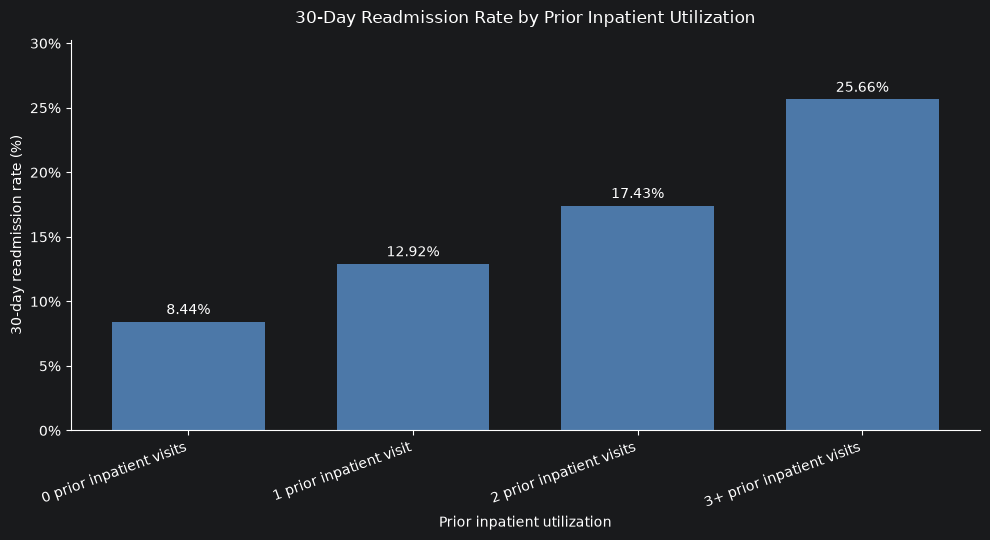

In [40]:
fig, ax = plt.subplots(figsize=(10, 5.5))
bars = ax.bar(
    inpatient_utilization_summary["inpatient_utilization_group"].astype(str),
    inpatient_utilization_summary["readmission_rate_pct"],
    color="#4C78A8",
    width=0.68,
)

ax.set_title("30-Day Readmission Rate by Prior Inpatient Utilization", pad=12)
ax.set_xlabel("Prior inpatient utilization")
ax.set_ylabel("30-day readmission rate (%)")
ax.yaxis.set_major_formatter("{x:.0f}%")
ax.bar_label(
    bars,
    labels=[f"{rate:.2f}%" for rate in inpatient_utilization_summary["readmission_rate_pct"]],
    padding=3,
)
ax.spines[["top", "right"]].set_visible(False)
ax.set_ylim(0, inpatient_utilization_summary["readmission_rate_pct"].max() * 1.18)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

## Prior emergency utilization

In [41]:
emergency_order = [
    "0 prior emergency visits",
    "1 prior emergency visit",
    "2+ prior emergency visits",
]
emergency_utilization_group = pd.cut(
    df["number_emergency"],
    bins=[-np.inf, 0, 1, np.inf],
    labels=emergency_order,
    ordered=True,
)

emergency_utilization_summary = (
    df.assign(emergency_utilization_group=emergency_utilization_group)
    .groupby("emergency_utilization_group", observed=False)
    .agg(
        total_encounters=("encounter_id", "size"),
        readmitted_within_30_days=("readmit_30_flag", "sum"),
    )
    .reindex(emergency_order)
    .reset_index()
)
emergency_utilization_summary["readmission_rate_pct"] = (
    emergency_utilization_summary["readmitted_within_30_days"]
    / emergency_utilization_summary["total_encounters"]
    * 100
).round(2)

emergency_utilization_summary

,emergency_utilization_group,total_encounters,readmitted_within_30_days,readmission_rate_pct
0,0 prior emergency visits,90380,9467,10.47
1,1 prior emergency visit,7677,1102,14.35
2,2+ prior emergency visits,3706,788,21.26


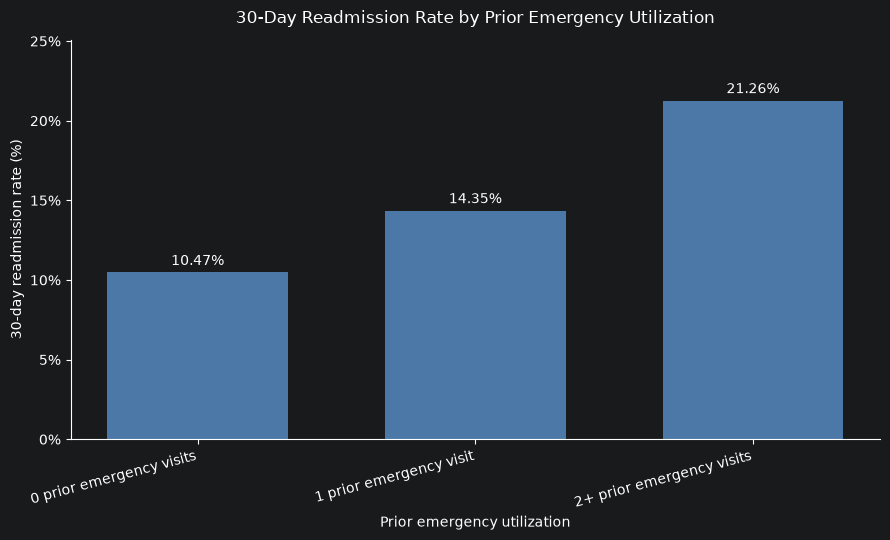

In [42]:
fig, ax = plt.subplots(figsize=(9, 5.5))
bars = ax.bar(
    emergency_utilization_summary["emergency_utilization_group"].astype(str),
    emergency_utilization_summary["readmission_rate_pct"],
    color="#4C78A8",
    width=0.65,
)

ax.set_title("30-Day Readmission Rate by Prior Emergency Utilization", pad=12)
ax.set_xlabel("Prior emergency utilization")
ax.set_ylabel("30-day readmission rate (%)")
ax.yaxis.set_major_formatter("{x:.0f}%")
ax.bar_label(
    bars,
    labels=[f"{rate:.2f}%" for rate in emergency_utilization_summary["readmission_rate_pct"]],
    padding=3,
)
ax.spines[["top", "right"]].set_visible(False)
ax.set_ylim(0, emergency_utilization_summary["readmission_rate_pct"].max() * 1.18)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

## Prior outpatient utilization

In [43]:
outpatient_order = [
    "0 prior outpatient visits",
    "1 prior outpatient visit",
    "2+ prior outpatient visits",
]
outpatient_utilization_group = pd.cut(
    df["number_outpatient"],
    bins=[-np.inf, 0, 1, np.inf],
    labels=outpatient_order,
    ordered=True,
)

outpatient_utilization_summary = (
    df.assign(outpatient_utilization_group=outpatient_utilization_group)
    .groupby("outpatient_utilization_group", observed=False)
    .agg(
        total_encounters=("encounter_id", "size"),
        readmitted_within_30_days=("readmit_30_flag", "sum"),
    )
    .reindex(outpatient_order)
    .reset_index()
)
outpatient_utilization_summary["readmission_rate_pct"] = (
    outpatient_utilization_summary["readmitted_within_30_days"]
    / outpatient_utilization_summary["total_encounters"]
    * 100
).round(2)

outpatient_utilization_summary

,outpatient_utilization_group,total_encounters,readmitted_within_30_days,readmission_rate_pct
0,0 prior outpatient visits,85024,9076,10.67
1,1 prior outpatient visit,8547,1190,13.92
2,2+ prior outpatient visits,8192,1091,13.32


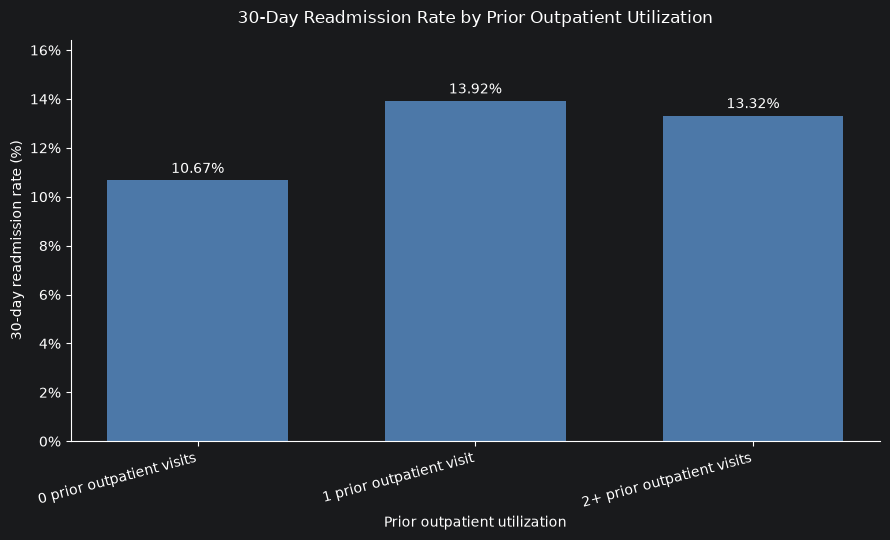

In [44]:
fig, ax = plt.subplots(figsize=(9, 5.5))
bars = ax.bar(
    outpatient_utilization_summary["outpatient_utilization_group"].astype(str),
    outpatient_utilization_summary["readmission_rate_pct"],
    color="#4C78A8",
    width=0.65,
)

ax.set_title("30-Day Readmission Rate by Prior Outpatient Utilization", pad=12)
ax.set_xlabel("Prior outpatient utilization")
ax.set_ylabel("30-day readmission rate (%)")
ax.yaxis.set_major_formatter("{x:.0f}%")
ax.bar_label(
    bars,
    labels=[f"{rate:.2f}%" for rate in outpatient_utilization_summary["readmission_rate_pct"]],
    padding=3,
)
ax.spines[["top", "right"]].set_visible(False)
ax.set_ylim(0, outpatient_utilization_summary["readmission_rate_pct"].max() * 1.18)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

## Validation

In [45]:
utilization_groups = [
    inpatient_utilization_group,
    emergency_utilization_group,
    outpatient_utilization_group,
]
utilization_summaries = [
    inpatient_utilization_summary,
    emergency_utilization_summary,
    outpatient_utilization_summary,
]

for utilization_group in utilization_groups:
    assert len(utilization_group) == len(df), "Utilization category length does not match df."
    assert utilization_group.notna().all(), "An encounter was not assigned a utilization category."

for utilization_summary in utilization_summaries:
    assert utilization_summary["total_encounters"].sum() == len(df), (
        "Utilization summary does not include every encounter."
    )
    assert utilization_summary["readmitted_within_30_days"].sum() == df["readmit_30_flag"].sum(), (
        "Utilization summary does not preserve the 30-day readmission total."
    )
    assert utilization_summary["readmission_rate_pct"].between(0, 100).all(), (
        "A utilization readmission rate falls outside the valid range."
    )

print("All utilization summaries include every encounter and preserve the readmission total.")

All utilization summaries include every encounter and preserve the readmission total.


### Interpretation

Prior inpatient utilization shows the clearest stepwise association with 30-day readmission in this dataset. The observed rate rises from 8.44% for 67,627 encounters with no prior inpatient visits to 12.92% for 19,521 encounters with one visit, 17.43% for 7,566 encounters with two visits, and 25.66% for 7,049 encounters with three or more visits.

Prior emergency utilization shows a similar pattern: rates rise from 10.47% across 90,380 encounters with no prior emergency visits to 14.35% across 7,677 encounters with one visit and 21.26% across 3,706 encounters with two or more visits. The highest-utilization group is much smaller and should be interpreted with that sample size in mind.

Prior outpatient utilization shows a less pronounced pattern. The observed rate is 10.67% across 85,024 encounters with no prior outpatient visits, 13.92% across 8,547 encounters with one visit, and 13.32% across 8,192 encounters with two or more visits. In this dataset, higher outpatient utilization is associated with higher rates than no outpatient utilization, but the rate does not increase stepwise from one visit to two or more visits. These are descriptive associations and do not establish causation.

# 4. Current Hospital Encounter Characteristics and 30-Day Readmission

Examine whether length of stay, medication burden, procedures, and laboratory testing during the current encounter are associated with 30-day readmission. This analysis uses the existing `df` DataFrame and `readmit_30_flag`; it does not alter the source dataset.

## Summary by readmission outcome

In [46]:
encounter_characteristics_by_outcome = (
    df.groupby("readmit_30_flag")
    .agg(
        mean_time_in_hospital=("time_in_hospital", "mean"),
        median_time_in_hospital=("time_in_hospital", "median"),
        mean_num_lab_procedures=("num_lab_procedures", "mean"),
        median_num_lab_procedures=("num_lab_procedures", "median"),
        mean_num_procedures=("num_procedures", "mean"),
        median_num_procedures=("num_procedures", "median"),
        mean_num_medications=("num_medications", "mean"),
        median_num_medications=("num_medications", "median"),
    )
    .round(2)
    .reset_index()
)
encounter_characteristics_by_outcome.insert(
    1,
    "readmission_outcome",
    encounter_characteristics_by_outcome["readmit_30_flag"].map(
        {0: "No 30-Day Readmission", 1: "30-Day Readmission"}
    ),
)

encounter_characteristics_by_outcome

,readmit_30_flag,readmission_outcome,mean_time_in_hospital,median_time_in_hospital,mean_num_lab_procedures,median_num_lab_procedures,mean_num_procedures,median_num_procedures,mean_num_medications,median_num_medications
0,0,No 30-Day Readmission,4.35,4.0,42.95,44.0,1.35,1.0,15.91,15.0
1,1,30-Day Readmission,4.77,4.0,44.23,45.0,1.28,1.0,16.90,16.0


Encounters followed by a 30-day readmission have somewhat higher mean values for length of stay (4.77 versus 4.35 days), laboratory procedures (44.23 versus 42.95), and medications (16.90 versus 15.91), but a slightly lower mean procedure count (1.28 versus 1.35). Median length of stay and procedure count are the same in both groups, while median medication count is one higher among readmitted encounters. These are modest descriptive differences and indicate association only.

## Length of stay

In [47]:
length_of_stay_distribution = df["time_in_hospital"].agg(
    minimum="min", maximum="max", median="median"
)
length_of_stay_counts = (
    df["time_in_hospital"].value_counts().sort_index().rename_axis("days").rename("encounters")
)

display(length_of_stay_distribution.to_frame("value"))
length_of_stay_counts.to_frame()

,value
minimum,1.0
maximum,14.0
median,4.0


,encounters
days,
1,14206
2,17224
3,17756
4,13924
5,9966
6,7539
7,5859
8,4390
9,3002


The observed values span 1–14 days, so the categories below cover the complete range with short (1–3 days), medium (4–7 days), and longer (8–14 days) stays.

In [48]:
length_of_stay_order = ["1–3 days", "4–7 days", "8–14 days"]
length_of_stay_group = pd.cut(
    df["time_in_hospital"],
    bins=[0, 3, 7, 14],
    labels=length_of_stay_order,
    include_lowest=True,
    ordered=True,
)

length_of_stay_summary = (
    df.assign(length_of_stay_group=length_of_stay_group)
    .groupby("length_of_stay_group", observed=False)
    .agg(
        total_encounters=("encounter_id", "size"),
        readmitted_within_30_days=("readmit_30_flag", "sum"),
    )
    .reindex(length_of_stay_order)
    .reset_index()
)
length_of_stay_summary["readmission_rate_pct"] = (
    length_of_stay_summary["readmitted_within_30_days"]
    / length_of_stay_summary["total_encounters"]
    * 100
).round(2)

length_of_stay_summary

,length_of_stay_group,total_encounters,readmitted_within_30_days,readmission_rate_pct
0,1–3 days,49186,4768,9.69
1,4–7 days,37288,4544,12.19
2,8–14 days,15289,2045,13.38


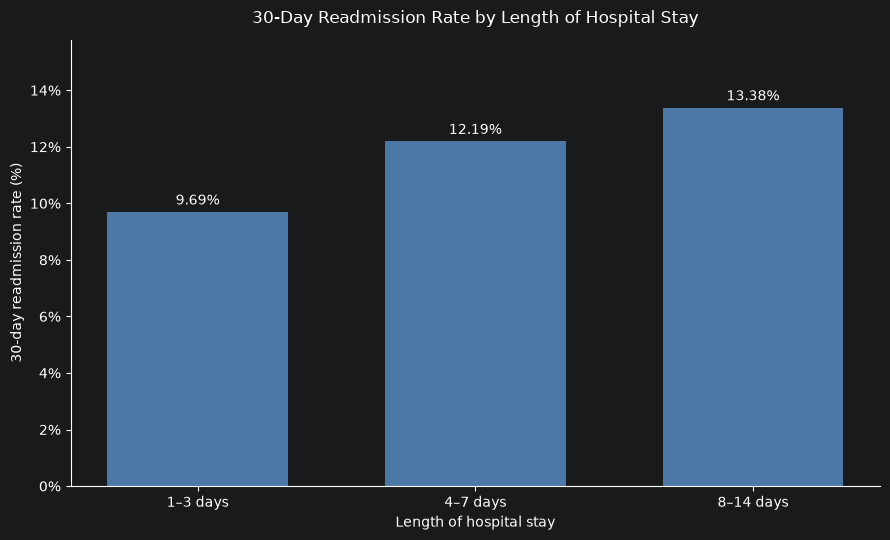

In [49]:
fig, ax = plt.subplots(figsize=(9, 5.5))
bars = ax.bar(
    length_of_stay_summary["length_of_stay_group"].astype(str),
    length_of_stay_summary["readmission_rate_pct"],
    color="#4C78A8",
    width=0.65,
)

ax.set_title("30-Day Readmission Rate by Length of Hospital Stay", pad=12)
ax.set_xlabel("Length of hospital stay")
ax.set_ylabel("30-day readmission rate (%)")
ax.yaxis.set_major_formatter("{x:.0f}%")
ax.bar_label(
    bars,
    labels=[f"{rate:.2f}%" for rate in length_of_stay_summary["readmission_rate_pct"]],
    padding=3,
)
ax.spines[["top", "right"]].set_visible(False)
ax.set_ylim(0, length_of_stay_summary["readmission_rate_pct"].max() * 1.18)
plt.tight_layout()
plt.show()

## Medication burden

In [50]:
medication_distribution = df["num_medications"].describe(
    percentiles=[0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
).to_frame("num_medications")
medication_distribution

,num_medications
count,101763.000000
mean,16.021835
std,8.127589
min,1.000000
10%,7.000000
25%,10.000000
50%,15.000000
75%,20.000000
90%,26.000000
95%,31.000000


Medication counts range from 1 to 81, with quartiles at 10, 15, and 20. The categories use these observed quartile boundaries, producing interpretable groups without very small samples.

In [51]:
medication_order = [
    "1–10 medications",
    "11–15 medications",
    "16–20 medications",
    "21+ medications",
]
medication_group = pd.cut(
    df["num_medications"],
    bins=[0, 10, 15, 20, np.inf],
    labels=medication_order,
    include_lowest=True,
    ordered=True,
)

medication_summary = (
    df.assign(medication_group=medication_group)
    .groupby("medication_group", observed=False)
    .agg(
        total_encounters=("encounter_id", "size"),
        readmitted_within_30_days=("readmit_30_flag", "sum"),
    )
    .reindex(medication_order)
    .reset_index()
)
medication_summary["readmission_rate_pct"] = (
    medication_summary["readmitted_within_30_days"]
    / medication_summary["total_encounters"]
    * 100
).round(2)

medication_summary

,medication_group,total_encounters,readmitted_within_30_days,readmission_rate_pct
0,1–10 medications,25860,2344,9.06
1,11–15 medications,29384,3206,10.91
2,16–20 medications,22641,2756,12.17
3,21+ medications,23878,3051,12.78


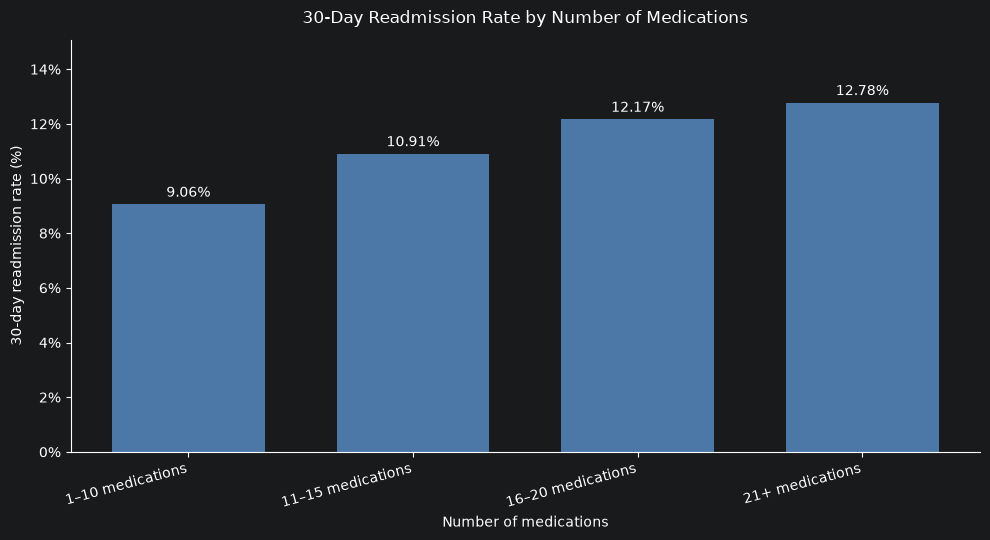

In [52]:
fig, ax = plt.subplots(figsize=(10, 5.5))
bars = ax.bar(
    medication_summary["medication_group"].astype(str),
    medication_summary["readmission_rate_pct"],
    color="#4C78A8",
    width=0.68,
)

ax.set_title("30-Day Readmission Rate by Number of Medications", pad=12)
ax.set_xlabel("Number of medications")
ax.set_ylabel("30-day readmission rate (%)")
ax.yaxis.set_major_formatter("{x:.0f}%")
ax.bar_label(
    bars,
    labels=[f"{rate:.2f}%" for rate in medication_summary["readmission_rate_pct"]],
    padding=3,
)
ax.spines[["top", "right"]].set_visible(False)
ax.set_ylim(0, medication_summary["readmission_rate_pct"].max() * 1.18)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

## Procedures and laboratory testing

In [53]:
procedure_lab_descriptive_stats = (
    df.groupby("readmit_30_flag")[["num_procedures", "num_lab_procedures"]]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .round(2)
)
procedure_lab_descriptive_stats.index = procedure_lab_descriptive_stats.index.map(
    {0: "No 30-Day Readmission", 1: "30-Day Readmission"}
)
procedure_lab_descriptive_stats.index.name = "readmission_outcome"
procedure_lab_descriptive_stats

num_procedures                             \
                               count  mean median   std min max   
readmission_outcome                                               
No 30-Day Readmission          90406  1.35    1.0  1.71   0   6   
30-Day Readmission             11357  1.28    1.0  1.64   0   6   

                      num_lab_procedures                                
                                   count   mean median    std min  max  
readmission_outcome                                                     
No 30-Day Readmission              90406  42.95   44.0  19.72   1  129  
30-Day Readmission                 11357  44.23   45.0  19.28   1  132

`num_procedures` has only seven observed values (0–6), with many encounters at zero; grouping 3–6 together retains a logical utilization progression and adequate sample sizes.

In [54]:
procedure_order = ["0 procedures", "1 procedure", "2 procedures", "3+ procedures"]
procedure_group = pd.cut(
    df["num_procedures"],
    bins=[-np.inf, 0, 1, 2, np.inf],
    labels=procedure_order,
    ordered=True,
)

procedure_summary = (
    df.assign(procedure_group=procedure_group)
    .groupby("procedure_group", observed=False)
    .agg(
        total_encounters=("encounter_id", "size"),
        readmitted_within_30_days=("readmit_30_flag", "sum"),
    )
    .reindex(procedure_order)
    .reset_index()
)
procedure_summary["readmission_rate_pct"] = (
    procedure_summary["readmitted_within_30_days"]
    / procedure_summary["total_encounters"]
    * 100
).round(2)

procedure_summary

,procedure_group,total_encounters,readmitted_within_30_days,readmission_rate_pct
0,0 procedures,46652,5168,11.08
1,1 procedure,20741,2532,12.21
2,2 procedures,12716,1422,11.18
3,3+ procedures,21654,2235,10.32


The laboratory groups are derived from the observed distribution: 30 is near the first quartile (31), and 56 is just below the third quartile (57). This yields three broad groups—1–30, 31–56, and 57 or more procedures—rather than many arbitrary bins.

In [55]:
lab_procedure_order = [
    "1–30 lab procedures",
    "31–56 lab procedures",
    "57+ lab procedures",
]
lab_procedure_group = pd.cut(
    df["num_lab_procedures"],
    bins=[0, 30, 56, np.inf],
    labels=lab_procedure_order,
    include_lowest=True,
    ordered=True,
)

lab_procedure_summary = (
    df.assign(lab_procedure_group=lab_procedure_group)
    .groupby("lab_procedure_group", observed=False)
    .agg(
        total_encounters=("encounter_id", "size"),
        readmitted_within_30_days=("readmit_30_flag", "sum"),
    )
    .reindex(lab_procedure_order)
    .reset_index()
)
lab_procedure_summary["readmission_rate_pct"] = (
    lab_procedure_summary["readmitted_within_30_days"]
    / lab_procedure_summary["total_encounters"]
    * 100
).round(2)

lab_procedure_summary

,lab_procedure_group,total_encounters,readmitted_within_30_days,readmission_rate_pct
0,1–30 lab procedures,24200,2445,10.10
1,31–56 lab procedures,51460,5811,11.29
2,57+ lab procedures,26103,3101,11.88


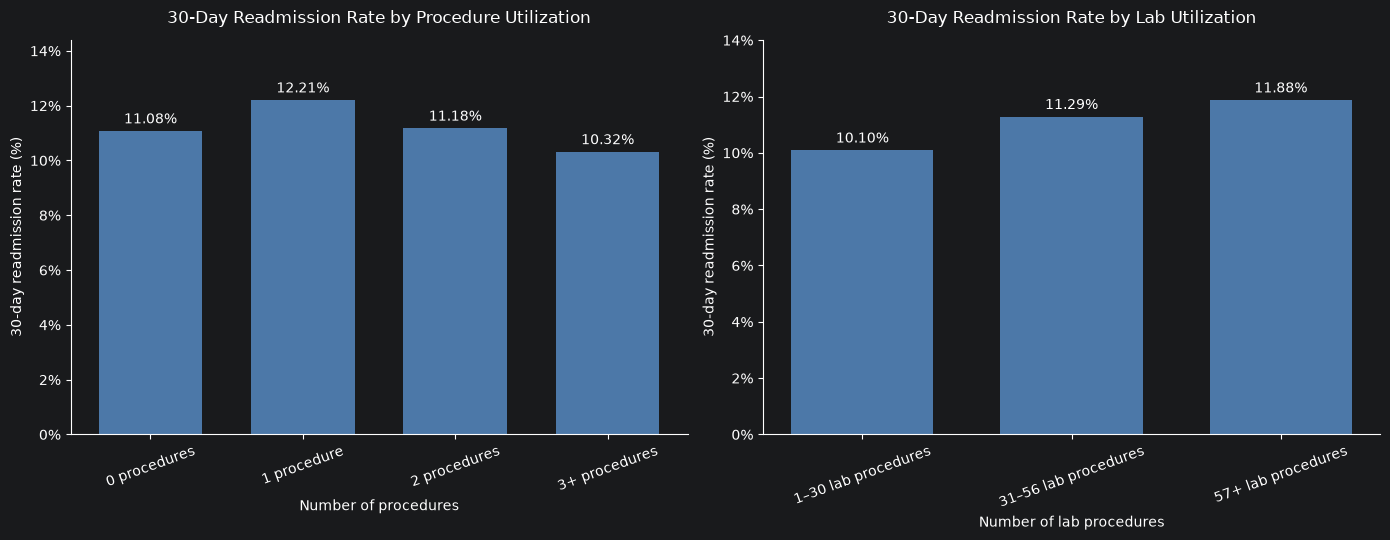

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

for ax, summary, category_column, title, xlabel in [
    (
        axes[0],
        procedure_summary,
        "procedure_group",
        "30-Day Readmission Rate by Procedure Utilization",
        "Number of procedures",
    ),
    (
        axes[1],
        lab_procedure_summary,
        "lab_procedure_group",
        "30-Day Readmission Rate by Lab Utilization",
        "Number of lab procedures",
    ),
]:
    bars = ax.bar(
        summary[category_column].astype(str),
        summary["readmission_rate_pct"],
        color="#4C78A8",
        width=0.68,
    )
    ax.set_title(title, pad=12)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("30-day readmission rate (%)")
    ax.yaxis.set_major_formatter("{x:.0f}%")
    ax.bar_label(
        bars,
        labels=[f"{rate:.2f}%" for rate in summary["readmission_rate_pct"]],
        padding=3,
    )
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_ylim(0, summary["readmission_rate_pct"].max() * 1.18)
    ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

## Validation

In [57]:
encounter_groups = [
    length_of_stay_group,
    medication_group,
    procedure_group,
    lab_procedure_group,
]
encounter_summaries = [
    length_of_stay_summary,
    medication_summary,
    procedure_summary,
    lab_procedure_summary,
]

for encounter_group in encounter_groups:
    assert len(encounter_group) == len(df), "Category length does not match df."
    assert encounter_group.notna().all(), "An encounter was not assigned a category."

for encounter_summary in encounter_summaries:
    assert encounter_summary["total_encounters"].sum() == len(df), (
        "A grouped summary does not include every encounter."
    )
    assert encounter_summary["readmitted_within_30_days"].sum() == df["readmit_30_flag"].sum(), (
        "A grouped summary does not preserve the 30-day readmission total."
    )
    assert encounter_summary["readmission_rate_pct"].between(0, 100).all(), (
        "A calculated readmission rate falls outside the valid range."
    )

print("All encounter-characteristic groups include every encounter and preserve the readmission total.")

All encounter-characteristic groups include every encounter and preserve the readmission total.


### Interpretation

Longer stays are associated with higher observed 30-day readmission rates in this dataset: 9.69% for 49,186 encounters lasting 1–3 days, 12.19% for 37,288 lasting 4–7 days, and 13.38% for 15,289 lasting 8–14 days. The largest increase occurs between the short- and medium-stay groups.

Medication burden shows a similarly consistent pattern across well-sized groups. The observed rate increases from 9.06% among 25,860 encounters with 1–10 medications to 12.78% among 23,878 encounters with 21 or more medications.

Procedure utilization does not show a stepwise relationship: the rate is highest for one procedure (12.21%) and lowest for three or more (10.32%). Laboratory utilization differs more consistently; readmitted encounters average 44.23 lab procedures versus 42.95 among non-readmitted encounters, and the grouped rates rise modestly across the three utilization levels.

Among these current-encounter characteristics, length of stay appears most informative because it shows the largest clear rate separation across categories, while medication burden also shows a meaningful graded association. The descriptive analysis suggests associations only and does not establish causation.